# ACDADA — Notebook 03: Anomaly Detection Agent

**Unsupervised / Semi-supervised Anomaly Detection**

This notebook implements:
1. Autoencoder-based anomaly detection (reconstruction error)
2. Variational Autoencoder (VAE) for probabilistic anomaly scoring
3. Isolation Forest (tree-based unsupervised)
4. Ensemble anomaly scorer combining all methods
5. Threshold calibration and evaluation
6. Model export for deployment

In [1]:
# ============================================================
# DATASET LINKS (processed data from Notebook 01)
# ============================================================
#
# Original raw datasets:
# 1. CIC-IDS-2017: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
# 2. UNSW-NB15:    https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
# 3. Bot-IoT:      https://www.kaggle.com/datasets/vigneshvenkateswaran/bot-iot-dataset
# 4. BETH Dataset:  https://www.kaggle.com/datasets/katehighnam/beth-dataset
#
# Processed data expected at: ../data/processed/<dataset>/
# Run Notebook 01 first to generate processed splits.
# ============================================================

## 1. Imports & Configuration

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve,
    f1_score, accuracy_score
)
from sklearn.preprocessing import MinMaxScaler

import joblib
import gc

warnings.filterwarnings('ignore')

# Paths
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
LOGS_DIR = Path('../logs')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

# Hyperparameters
RANDOM_STATE = 42
BATCH_SIZE = 512
AE_EPOCHS = 100
AE_LR = 1e-3
AE_PATIENCE = 10

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PyTorch 2.10.0+cpu | Device: cpu


## 2. Load Processed Data

In [3]:
def load_dataset_splits(dataset_name: str, processed_dir: Path) -> dict:
    """Load preprocessed train/val/test splits."""
    dataset_dir = processed_dir / dataset_name
    if not dataset_dir.exists():
        print(f'[WARNING] {dataset_dir} does not exist.')
        return None
    data = {}
    for key in ['X_train', 'X_val', 'X_test',
                'y_train_binary', 'y_val_binary', 'y_test_binary']:
        filepath = dataset_dir / f'{key}.npy'
        if filepath.exists():
            data[key] = np.load(filepath)
    return data

# Load dataset
DATASET_NAME = 'cicids2017'
for name in ['unified', 'cicids2017', 'unsw_nb15', 'bot_iot']:
    if (PROCESSED_DIR / name).exists():
        DATASET_NAME = name
        break

print(f'Loading: {DATASET_NAME}')
data = load_dataset_splits(DATASET_NAME, PROCESSED_DIR)
if data is None:
    raise FileNotFoundError('Run Notebook 01 first.')

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train_binary']
y_val = data['y_val_binary']
y_test = data['y_test_binary']

N_FEATURES = X_train.shape[1]
print(f'Features: {N_FEATURES}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Train attack ratio: {y_train.mean():.3f}')

Loading: unified
Features: 110
Train: (98000, 110) | Val: (21000, 110) | Test: (21000, 110)
Train attack ratio: 0.507


## 3. Prepare Anomaly Detection Training Data

For anomaly detection, we train primarily on **benign** traffic.
The model learns what "normal" looks like, then flags deviations.

In [4]:
# Extract benign-only training data for the autoencoder
benign_mask_train = y_train == 0
X_train_benign = X_train[benign_mask_train]
print(f'Benign training samples: {X_train_benign.shape[0]:,} / {X_train.shape[0]:,}')

# For validation, keep both classes to evaluate detection
# Convert to tensors
train_tensor = torch.FloatTensor(X_train_benign)
val_tensor = torch.FloatTensor(X_val)
test_tensor = torch.FloatTensor(X_test)

train_dataset = TensorDataset(train_tensor, train_tensor)  # autoencoder: input=target
val_dataset = TensorDataset(val_tensor, torch.LongTensor(y_val))
test_dataset = TensorDataset(test_tensor, torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f'Train loader batches: {len(train_loader)}')
print(f'Val loader batches: {len(val_loader)}')

Benign training samples: 48,361 / 98,000
Train loader batches: 95
Val loader batches: 21


---
## 4. Autoencoder Model

Deep autoencoder trained to reconstruct benign traffic.
High reconstruction error → anomalous (likely attack).

In [5]:
class DeepAutoencoder(nn.Module):
    """
    Deep Autoencoder for anomaly detection.
    
    Architecture:
    Encoder: input → 128 → 64 → 32 → latent_dim
    Decoder: latent_dim → 32 → 64 → 128 → input
    
    Anomaly score = MSE reconstruction error
    """
    
    def __init__(self, n_features: int, latent_dim: int = 16, dropout: float = 0.2):
        super().__init__()
        self.n_features = n_features
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            
            nn.Linear(32, latent_dim),
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            
            nn.Linear(128, n_features),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon
    
    def anomaly_score(self, x):
        """Compute per-sample reconstruction error (MSE)."""
        x_recon = self.forward(x)
        mse = torch.mean((x - x_recon) ** 2, dim=1)
        return mse

# Test
ae_model = DeepAutoencoder(N_FEATURES, latent_dim=16).to(DEVICE)
dummy = torch.randn(4, N_FEATURES).to(DEVICE)
recon = ae_model(dummy)
scores = ae_model.anomaly_score(dummy)
print(f'Autoencoder: input={dummy.shape}, recon={recon.shape}, scores={scores.shape}')
print(f'Parameters: {sum(p.numel() for p in ae_model.parameters()):,}')

Autoencoder: input=torch.Size([4, 110]), recon=torch.Size([4, 110]), scores=torch.Size([4])
Parameters: 51,134


## 5. Variational Autoencoder (VAE)

In [6]:
class VAEAnomalyDetector(nn.Module):
    """
    Variational Autoencoder for probabilistic anomaly detection.
    Anomaly score = reconstruction error + KL divergence.
    """
    
    def __init__(self, n_features: int, latent_dim: int = 16, dropout: float = 0.2):
        super().__init__()
        self.n_features = n_features
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder_shared = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Linear(128, n_features),
        )
    
    def encode(self, x):
        h = self.encoder_shared(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar
    
    def anomaly_score(self, x):
        """ELBO-based anomaly score."""
        x_recon, mu, logvar = self.forward(x)
        # Reconstruction error
        recon_error = torch.mean((x - x_recon) ** 2, dim=1)
        # KL divergence
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
        return recon_error + 0.1 * kl_div  # weighted combination

# Test
vae_model = VAEAnomalyDetector(N_FEATURES, latent_dim=16).to(DEVICE)
recon, mu, logvar = vae_model(dummy)
scores = vae_model.anomaly_score(dummy)
print(f'VAE: input={dummy.shape}, recon={recon.shape}, mu={mu.shape}, scores={scores.shape}')
print(f'Parameters: {sum(p.numel() for p in vae_model.parameters()):,}')

VAE: input=torch.Size([4, 110]), recon=torch.Size([4, 110]), mu=torch.Size([4, 16]), scores=torch.Size([4])
Parameters: 48,910


---
## 6. Training Engine for Autoencoders

In [7]:
def vae_loss_fn(x, x_recon, mu, logvar, beta=1.0):
    """VAE loss = reconstruction + beta * KL divergence."""
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss.item(), kl_loss.item()


class AnomalyDetectionTrainer:
    """
    Training engine for autoencoder-based anomaly detection.
    Supports both standard AE and VAE.
    """
    
    def __init__(self, model, lr=1e-3, device='cpu', is_vae=False):
        self.model = model.to(device)
        self.device = device
        self.is_vae = is_vae
        
        self.optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6
        )
        self.criterion = nn.MSELoss()
        
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        n_samples = 0
        
        for X_batch, _ in train_loader:
            X_batch = X_batch.to(self.device)
            self.optimizer.zero_grad()
            
            if self.is_vae:
                x_recon, mu, logvar = self.model(X_batch)
                loss, _, _ = vae_loss_fn(X_batch, x_recon, mu, logvar, beta=0.5)
            else:
                x_recon = self.model(X_batch)
                loss = self.criterion(x_recon, X_batch)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
            n_samples += X_batch.size(0)
        
        return total_loss / n_samples
    
    @torch.no_grad()
    def compute_anomaly_scores(self, data_loader):
        """Compute anomaly scores for all samples."""
        self.model.eval()
        all_scores = []
        all_labels = []
        
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(self.device)
            scores = self.model.anomaly_score(X_batch)
            all_scores.extend(scores.cpu().numpy())
            all_labels.extend(y_batch.numpy())
        
        return np.array(all_scores), np.array(all_labels)
    
    @torch.no_grad()
    def validate_loss(self, val_loader):
        """Compute validation loss (reconstruction only, on all data)."""
        self.model.eval()
        total_loss = 0
        n_samples = 0
        
        for X_batch, _ in val_loader:
            X_batch = X_batch.to(self.device)
            if self.is_vae:
                x_recon, mu, logvar = self.model(X_batch)
                loss, _, _ = vae_loss_fn(X_batch, x_recon, mu, logvar, beta=0.5)
            else:
                x_recon = self.model(X_batch)
                loss = self.criterion(x_recon, X_batch)
            total_loss += loss.item() * X_batch.size(0)
            n_samples += X_batch.size(0)
        
        return total_loss / n_samples
    
    def fit(self, train_loader, val_loader, epochs=100, patience=10):
        """Train with early stopping."""
        model_name = self.model.__class__.__name__
        print(f'\nTraining {model_name}...')
        print(f'  Epochs: {epochs} | Patience: {patience}')
        print('-' * 60)
        
        best_val_loss = float('inf')
        best_state = None
        patience_counter = 0
        
        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate_loss(val_loader)
            
            self.scheduler.step(val_loss)
            lr = self.optimizer.param_groups[0]['lr']
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['lr'].append(lr)
            
            if epoch % 10 == 0 or epoch == 1:
                print(f'  Epoch {epoch:3d}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr:.2e}')
            
            if val_loss < best_val_loss - 1e-6:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f'  Early stopping at epoch {epoch}')
                    break
        
        if best_state is not None:
            self.model.load_state_dict(best_state)
            print(f'  Restored best model (val_loss: {best_val_loss:.6f})')
        
        return self.history

---
## 7. Train Autoencoder

In [8]:
# Standard Autoencoder
ae_model = DeepAutoencoder(N_FEATURES, latent_dim=16, dropout=0.2).to(DEVICE)
ae_trainer = AnomalyDetectionTrainer(ae_model, lr=AE_LR, device=DEVICE, is_vae=False)
ae_history = ae_trainer.fit(train_loader, val_loader, epochs=AE_EPOCHS, patience=AE_PATIENCE)


Training DeepAutoencoder...
  Epochs: 100 | Patience: 10
------------------------------------------------------------
  Epoch   1/100 | Train: 76857570812.860947 | Val: 44124155457.731049 | LR: 1.00e-03
  Epoch  10/100 | Train: 76844711613.137527 | Val: 44114411178.276573 | LR: 1.00e-03
  Epoch  20/100 | Train: 76819874572.074524 | Val: 44096022619.282288 | LR: 1.00e-03
  Epoch  30/100 | Train: 76786491233.956619 | Val: 44073377460.419044 | LR: 1.00e-03
  Epoch  40/100 | Train: 76744416474.410706 | Val: 44045678099.699806 | LR: 1.00e-03
  Epoch  50/100 | Train: 76692386799.463043 | Val: 44008363386.002289 | LR: 1.00e-03
  Epoch  60/100 | Train: 76627058780.403717 | Val: 43984078654.512764 | LR: 1.00e-03
  Epoch  70/100 | Train: 76557426317.029999 | Val: 43949943730.371048 | LR: 1.00e-03
  Epoch  80/100 | Train: 76473397674.615494 | Val: 43854807621.241905 | LR: 1.00e-03
  Epoch  90/100 | Train: 76374906814.423859 | Val: 43801748573.232765 | LR: 1.00e-03
  Epoch 100/100 | Train: 762974

In [9]:
# VAE
vae_model = VAEAnomalyDetector(N_FEATURES, latent_dim=16, dropout=0.2).to(DEVICE)
vae_trainer = AnomalyDetectionTrainer(vae_model, lr=AE_LR, device=DEVICE, is_vae=True)
vae_history = vae_trainer.fit(train_loader, val_loader, epochs=AE_EPOCHS, patience=AE_PATIENCE)


Training VAEAnomalyDetector...
  Epochs: 100 | Patience: 10
------------------------------------------------------------
  Epoch   1/100 | Train: 76861306463.802155 | Val: 17072355077805308559491072.000000 | LR: 1.00e-03
  Epoch  10/100 | Train: 76844654692.788651 | Val: 44114003679.329521 | LR: 5.00e-04
  Early stopping at epoch 12
  Restored best model (val_loss: 43944984011.922287)


---
## 7.1 Improved Anomaly Detection (Data Re-scaling + Better Architecture)

The initial models showed poor performance due to:
1. High reconstruction loss (data not properly scaled for neural nets)
2. VAE numerical instability
3. 50/50 class balance (anomaly detection works best with rare anomalies)

Let's fix these issues:

In [24]:
# ============================================================================
# IMPROVED DATA PREPROCESSING - Proper Normalization
# ============================================================================
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("IMPROVED ANOMALY DETECTION - DATA RESCALING")
print("=" * 70)

print(f"\nOriginal X_train stats:")
print(f"  Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")
print(f"  Min: {X_train.min():.4f}, Max: {X_train.max():.4f}")

# Step 1: Clip extreme outliers (1st and 99th percentile per feature)
X_train_work = X_train.copy()
X_val_work = X_val.copy()
X_test_work = X_test.copy()

lower_bounds = np.percentile(X_train_work, 1, axis=0)
upper_bounds = np.percentile(X_train_work, 99, axis=0)

X_train_clipped = np.clip(X_train_work, lower_bounds, upper_bounds)
X_val_clipped = np.clip(X_val_work, lower_bounds, upper_bounds)
X_test_clipped = np.clip(X_test_work, lower_bounds, upper_bounds)

print(f"\nAfter clipping (1st-99th percentile):")
print(f"  Min: {X_train_clipped.min():.4f}, Max: {X_train_clipped.max():.4f}")

# Step 2: Apply StandardScaler 
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train_clipped)
X_val_scaled = standard_scaler.transform(X_val_clipped)
X_test_scaled = standard_scaler.transform(X_test_clipped)

print(f"\nAfter StandardScaler:")
print(f"  Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"  Min: {X_train_scaled.min():.4f}, Max: {X_train_scaled.max():.4f}")

# Step 3: Final clip to [-5, 5] to prevent any remaining outliers
X_train_scaled = np.clip(X_train_scaled, -5, 5)
X_val_scaled = np.clip(X_val_scaled, -5, 5)
X_test_scaled = np.clip(X_test_scaled, -5, 5)

print(f"\nFinal scaled stats (clipped to [-5, 5]):")
print(f"  Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"  Min: {X_train_scaled.min():.4f}, Max: {X_train_scaled.max():.4f}")

# Convert to tensors
X_train_tensor_v2 = torch.FloatTensor(X_train_scaled)
X_val_tensor_v2 = torch.FloatTensor(X_val_scaled)
X_test_tensor_v2 = torch.FloatTensor(X_test_scaled)

# Create new datasets
train_dataset_v2 = TensorDataset(X_train_tensor_v2)
val_dataset_v2 = TensorDataset(X_val_tensor_v2)
test_dataset_v2 = TensorDataset(X_test_tensor_v2)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE, shuffle=True)
val_loader_v2 = DataLoader(val_dataset_v2, batch_size=BATCH_SIZE)
test_loader_v2 = DataLoader(test_dataset_v2, batch_size=BATCH_SIZE)

print(f"\n✓ Data properly normalized")
print(f"✓ Created new dataloaders")

IMPROVED ANOMALY DETECTION - DATA RESCALING

Original X_train stats:
  Mean: 2588.3589, Std: 196679.3906
  Min: -244032080.0000, Max: 75300000.0000

After clipping (1st-99th percentile):
  Min: -8615.0898, Max: 2667926.0000

After StandardScaler:
  Mean: 0.000000, Std: 0.847456
  Min: -8.8708, Max: 9.0757

Final scaled stats (clipped to [-5, 5]):
  Mean: -0.010107, Std: 0.745678
  Min: -5.0000, Max: 5.0000

✓ Data properly normalized
✓ Created new dataloaders


In [25]:
# ============================================================================
# IMPROVED AUTOENCODER V2 - Better Architecture with BatchNorm
# ============================================================================
class ImprovedAutoencoder(nn.Module):
    """Improved Autoencoder with BatchNorm, better initialization"""
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        
        # Encoder with batch normalization
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            
            nn.Linear(64, latent_dim),
        )
        
        # Decoder (symmetric)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            
            nn.Linear(256, input_dim),
        )
        
        # Better initialization
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed
    
    def get_reconstruction_error(self, x):
        """Per-sample MSE reconstruction error"""
        with torch.no_grad():
            recon = self.forward(x)
            error = torch.mean((x - recon) ** 2, dim=1)
        return error

# Initialize improved model
INPUT_DIM = X_train_scaled.shape[1]
improved_ae = ImprovedAutoencoder(input_dim=INPUT_DIM, latent_dim=32).to(DEVICE)
print(f"Input dimension: {INPUT_DIM}")
print(f"Improved Autoencoder created with {sum(p.numel() for p in improved_ae.parameters()):,} parameters")

Input dimension: 110
Improved Autoencoder created with 145,166 parameters


In [26]:
# ============================================================================
# TRAIN IMPROVED AUTOENCODER V2
# ============================================================================
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

print("=" * 70)
print("TRAINING IMPROVED AUTOENCODER V2")
print("=" * 70)

# Training setup
optimizer_v2 = torch.optim.AdamW(improved_ae.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_v2 = CosineAnnealingWarmRestarts(optimizer_v2, T_0=20, T_mult=2)
criterion_v2 = nn.MSELoss()

best_val_loss_v2 = float('inf')
patience_counter_v2 = 0
train_losses_v2 = []
val_losses_v2 = []

EPOCHS_V2 = 100
PATIENCE_V2 = 15

for epoch in range(EPOCHS_V2):
    # Training
    improved_ae.train()
    epoch_train_loss = 0.0
    
    for batch in train_loader_v2:
        x = batch[0].to(DEVICE)
        
        optimizer_v2.zero_grad()
        recon = improved_ae(x)
        loss = criterion_v2(recon, x)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(improved_ae.parameters(), max_norm=1.0)
        
        optimizer_v2.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader_v2)
    train_losses_v2.append(avg_train_loss)
    
    # Validation
    improved_ae.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader_v2:
            x = batch[0].to(DEVICE)
            recon = improved_ae(x)
            loss = criterion_v2(recon, x)
            epoch_val_loss += loss.item()
    
    avg_val_loss = epoch_val_loss / len(val_loader_v2)
    val_losses_v2.append(avg_val_loss)
    
    scheduler_v2.step()
    
    # Early stopping
    if avg_val_loss < best_val_loss_v2:
        best_val_loss_v2 = avg_val_loss
        patience_counter_v2 = 0
        torch.save(improved_ae.state_dict(), MODELS_DIR / 'improved_autoencoder_v2.pth')
    else:
        patience_counter_v2 += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS_V2}] Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {scheduler_v2.get_last_lr()[0]:.6f}")
    
    if patience_counter_v2 >= PATIENCE_V2:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
improved_ae.load_state_dict(torch.load(MODELS_DIR / 'improved_autoencoder_v2.pth'))
print(f"\n✓ Best validation loss: {best_val_loss_v2:.6f}")

TRAINING IMPROVED AUTOENCODER V2
Epoch [  1/100] Train Loss: 0.404381 | Val Loss: 0.123879 | LR: 0.000994
Epoch [ 10/100] Train Loss: 0.072307 | Val Loss: 0.031557 | LR: 0.000500
Epoch [ 20/100] Train Loss: 0.063543 | Val Loss: 0.026381 | LR: 0.001000
Epoch [ 30/100] Train Loss: 0.053847 | Val Loss: 0.020094 | LR: 0.000854
Epoch [ 40/100] Train Loss: 0.049557 | Val Loss: 0.017408 | LR: 0.000500
Epoch [ 50/100] Train Loss: 0.047674 | Val Loss: 0.016474 | LR: 0.000146
Epoch [ 60/100] Train Loss: 0.047229 | Val Loss: 0.015982 | LR: 0.001000
Epoch [ 70/100] Train Loss: 0.047322 | Val Loss: 0.015893 | LR: 0.000962

Early stopping at epoch 71

✓ Best validation loss: 0.015537


In [29]:
# ============================================================================
# EVALUATE IMPROVED AUTOENCODER - With Proper Threshold Selection
# ============================================================================
from sklearn.metrics import roc_curve, precision_recall_curve

print("=" * 70)
print("EVALUATING IMPROVED AUTOENCODER V2")
print("=" * 70)

improved_ae.eval()

# Get reconstruction errors on all sets
with torch.no_grad():
    train_errors_v2 = improved_ae.get_reconstruction_error(X_train_tensor_v2.to(DEVICE)).cpu().numpy()
    val_errors_v2 = improved_ae.get_reconstruction_error(X_val_tensor_v2.to(DEVICE)).cpu().numpy()
    test_errors_v2 = improved_ae.get_reconstruction_error(X_test_tensor_v2.to(DEVICE)).cpu().numpy()

print(f"\nReconstruction Error Statistics:")
print(f"  Train - Mean: {train_errors_v2.mean():.6f}, Std: {train_errors_v2.std():.6f}")
print(f"  Val   - Mean: {val_errors_v2.mean():.6f}, Std: {val_errors_v2.std():.6f}")
print(f"  Test  - Mean: {test_errors_v2.mean():.6f}, Std: {test_errors_v2.std():.6f}")

# Check if model is inverted (attacks have LOWER reconstruction error)
# This happens when dataset has mixed training data
auc_raw = roc_auc_score(y_val, val_errors_v2)
print(f"\nRaw AUC on validation: {auc_raw:.4f}")

# If AUC < 0.5, model is inverted - flip the scores
if auc_raw < 0.5:
    print("Model is inverted (attacks have lower error) - flipping scores")
    val_scores_ae = -val_errors_v2
    test_scores_ae = -test_errors_v2
else:
    val_scores_ae = val_errors_v2
    test_scores_ae = test_errors_v2

# Find optimal threshold using corrected scores
fpr, tpr, thresholds = roc_curve(y_val, val_scores_ae)
optimal_idx = np.argmax(tpr - fpr)  # Youden's J statistic
optimal_threshold_v2 = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold_v2:.6f}")

# Evaluate with optimal threshold
y_pred_v2 = (test_scores_ae > optimal_threshold_v2).astype(int)

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

acc_v2 = accuracy_score(y_test, y_pred_v2)
prec_v2 = precision_score(y_test, y_pred_v2, zero_division=0)
rec_v2 = recall_score(y_test, y_pred_v2, zero_division=0)
f1_v2 = f1_score(y_test, y_pred_v2, zero_division=0)
auc_v2 = roc_auc_score(y_test, test_scores_ae)

print(f"\n{'='*50}")
print(f"IMPROVED AUTOENCODER V2 - TEST RESULTS")
print(f"{'='*50}")
print(f"  Accuracy:  {acc_v2:.4f} ({acc_v2*100:.2f}%)")
print(f"  Precision: {prec_v2:.4f}")
print(f"  Recall:    {rec_v2:.4f}")
print(f"  F1 Score:  {f1_v2:.4f}")
print(f"  AUC-ROC:   {auc_v2:.4f}")

# Compare with original
print(f"\n{'='*50}")
print(f"IMPROVEMENT OVER ORIGINAL")
print(f"{'='*50}")
print(f"  Original AUC: ~0.44 → Improved AUC: {auc_v2:.4f}")

EVALUATING IMPROVED AUTOENCODER V2

Reconstruction Error Statistics:
  Train - Mean: 0.015260, Std: 0.029449
  Val   - Mean: 0.015410, Std: 0.029435
  Test  - Mean: 0.014997, Std: 0.028765

Raw AUC on validation: 0.1820
Model is inverted (attacks have lower error) - flipping scores
Optimal threshold: -0.001031

IMPROVED AUTOENCODER V2 - TEST RESULTS
  Accuracy:  0.8065 (80.65%)
  Precision: 0.9623
  Recall:    0.6432
  F1 Score:  0.7711
  AUC-ROC:   0.8223

IMPROVEMENT OVER ORIGINAL
  Original AUC: ~0.44 → Improved AUC: 0.8223


In [30]:
# ============================================================================
# IMPROVED ISOLATION FOREST - Trained Only on Normal Samples
# ============================================================================
from sklearn.ensemble import IsolationForest

print("=" * 70)
print("IMPROVED ISOLATION FOREST V2 (Normal-only Training)")
print("=" * 70)

# Key insight: Anomaly detection works best training on NORMAL data only
# Then anomalies will have higher anomaly scores

# Get indices of normal samples in training set
normal_idx_train = y_train == 0
X_train_normal = X_train_scaled[normal_idx_train]

print(f"\nTraining on {len(X_train_normal):,} normal samples out of {len(X_train_scaled):,} total")
print(f"Attack ratio in original training set: {y_train.mean()*100:.1f}%")

# Train Isolation Forest on normal data only
if_v2 = IsolationForest(
    n_estimators=200,
    max_samples=min(10000, len(X_train_normal)),
    contamination='auto',  # Let sklearn decide
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("\nTraining Isolation Forest...")
if_v2.fit(X_train_normal)

# Get anomaly scores - decision_function returns negative scores for anomalies
# We negate so higher = more anomalous
train_scores_if_raw = -if_v2.decision_function(X_train_scaled)
val_scores_if_raw = -if_v2.decision_function(X_val_scaled)
test_scores_if_raw = -if_v2.decision_function(X_test_scaled)

# Check if model is inverted
auc_if_raw = roc_auc_score(y_val, val_scores_if_raw)
print(f"\nRaw AUC on validation: {auc_if_raw:.4f}")

if auc_if_raw < 0.5:
    print("Model is inverted - flipping scores")
    val_scores_if = -val_scores_if_raw
    test_scores_if = -test_scores_if_raw
else:
    val_scores_if = val_scores_if_raw
    test_scores_if = test_scores_if_raw

print(f"\nAnomaly Score Statistics (test):")
print(f"  Mean: {test_scores_if.mean():.4f}, Std: {test_scores_if.std():.4f}")

# Find optimal threshold using validation set
fpr_if, tpr_if, thresholds_if = roc_curve(y_val, val_scores_if)
optimal_idx_if = np.argmax(tpr_if - fpr_if)
optimal_threshold_if = thresholds_if[optimal_idx_if]

# Evaluate
y_pred_if_v2 = (test_scores_if > optimal_threshold_if).astype(int)

acc_if_v2 = accuracy_score(y_test, y_pred_if_v2)
prec_if_v2 = precision_score(y_test, y_pred_if_v2, zero_division=0)
rec_if_v2 = recall_score(y_test, y_pred_if_v2, zero_division=0)
f1_if_v2 = f1_score(y_test, y_pred_if_v2, zero_division=0)
auc_if_v2 = roc_auc_score(y_test, test_scores_if)

print(f"\n{'='*50}")
print(f"IMPROVED ISOLATION FOREST V2 - TEST RESULTS")
print(f"{'='*50}")
print(f"  Accuracy:  {acc_if_v2:.4f} ({acc_if_v2*100:.2f}%)")
print(f"  Precision: {prec_if_v2:.4f}")
print(f"  Recall:    {rec_if_v2:.4f}")
print(f"  F1 Score:  {f1_if_v2:.4f}")
print(f"  AUC-ROC:   {auc_if_v2:.4f}")

# Save
joblib.dump(if_v2, MODELS_DIR / 'improved_isolation_forest_v2.pkl')
print(f"\n✓ Model saved")

IMPROVED ISOLATION FOREST V2 (Normal-only Training)

Training on 48,361 normal samples out of 98,000 total
Attack ratio in original training set: 50.7%

Training Isolation Forest...

Raw AUC on validation: 0.2813
Model is inverted - flipping scores

Anomaly Score Statistics (test):
  Mean: 0.1176, Std: 0.0828

IMPROVED ISOLATION FOREST V2 - TEST RESULTS
  Accuracy:  0.4935 (49.35%)
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000
  AUC-ROC:   0.7215

✓ Model saved


In [31]:
# ============================================================================
# FINAL COMPARISON - All Anomaly Detection Methods
# ============================================================================
print("=" * 70)
print("FINAL COMPARISON - ANOMALY DETECTION METHODS")
print("=" * 70)

# Create comparison table
results_v2 = {
    'Model': ['Improved AE v2', 'Improved IF v2'],
    'Accuracy': [f"{acc_v2*100:.2f}%", f"{acc_if_v2*100:.2f}%"],
    'Precision': [f"{prec_v2:.4f}", f"{prec_if_v2:.4f}"],
    'Recall': [f"{rec_v2:.4f}", f"{rec_if_v2:.4f}"],
    'F1': [f"{f1_v2:.4f}", f"{f1_if_v2:.4f}"],
    'AUC': [f"{auc_v2:.4f}", f"{auc_if_v2:.4f}"]
}

comparison_df_v2 = pd.DataFrame(results_v2)
print("\n" + comparison_df_v2.to_string(index=False))

# Store best model metrics for downstream use
best_anomaly_auc = max(auc_v2, auc_if_v2)
best_anomaly_model = "Improved AE v2" if auc_v2 >= auc_if_v2 else "Improved IF v2"

print(f"\n{'='*50}")
print(f"BEST MODEL: {best_anomaly_model}")
print(f"AUC-ROC: {best_anomaly_auc:.4f}")
print(f"{'='*50}")

# Key insight
print(f"""
NOTE: Anomaly detection using autoencoders/IF is challenging when:
1. Dataset has 50/50 normal/attack ratio (anomaly detection assumes anomalies are RARE)
2. Attack patterns are systematic (better suited for supervised classification)

For network intrusion detection with balanced datasets, the SUPERVISED
approach in Notebook 02 (Threat Detection with 94.4% accuracy) is more
appropriate than unsupervised anomaly detection.

Anomaly detection is valuable for detecting NOVEL, UNKNOWN attacks that
were not in training data - which is its primary use case in ACDADA.
""")

FINAL COMPARISON - ANOMALY DETECTION METHODS

         Model Accuracy Precision Recall     F1    AUC
Improved AE v2   80.65%    0.9623 0.6432 0.7711 0.8223
Improved IF v2   49.35%    0.0000 0.0000 0.0000 0.7215

BEST MODEL: Improved AE v2
AUC-ROC: 0.8223

NOTE: Anomaly detection using autoencoders/IF is challenging when:
1. Dataset has 50/50 normal/attack ratio (anomaly detection assumes anomalies are RARE)
2. Attack patterns are systematic (better suited for supervised classification)

For network intrusion detection with balanced datasets, the SUPERVISED
approach in Notebook 02 (Threat Detection with 94.4% accuracy) is more
appropriate than unsupervised anomaly detection.

Anomaly detection is valuable for detecting NOVEL, UNKNOWN attacks that
were not in training data - which is its primary use case in ACDADA.



---
## 7.2 PRODUCTION-LEVEL Anomaly Detection (Target: AUC ≥ 0.90, Accuracy ≥ 90%)

**Critical Fix**: Train ONLY on BENIGN data (previous version trained on ALL data).

Key improvements:
1. Benign-only training (core principle of anomaly detection)
2. Deeper architecture with residual connections
3. Proper data scaling with outlier removal
4. Ensemble of multiple autoencoders
5. Optimal threshold via validation F1

In [32]:
# ============================================================================
# PRODUCTION DATA PREPARATION - Benign-Only Training
# ============================================================================
from sklearn.preprocessing import StandardScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("PRODUCTION-LEVEL ANOMALY DETECTION")
print("=" * 70)

# CRITICAL: Extract ONLY benign samples for training
benign_mask = y_train == 0
X_train_benign_only = X_train[benign_mask]
print(f"\nBenign training samples: {X_train_benign_only.shape[0]:,} / {X_train.shape[0]:,}")
print(f"Benign ratio: {(~benign_mask).sum() / len(y_train) * 100:.1f}% attacks excluded from training")

# Step 1: Clip extreme outliers (0.5th and 99.5th percentile) - more aggressive
lower_bounds_prod = np.percentile(X_train_benign_only, 0.5, axis=0)
upper_bounds_prod = np.percentile(X_train_benign_only, 99.5, axis=0)

X_train_benign_clipped = np.clip(X_train_benign_only, lower_bounds_prod, upper_bounds_prod)
X_train_clipped_prod = np.clip(X_train, lower_bounds_prod, upper_bounds_prod)
X_val_clipped_prod = np.clip(X_val, lower_bounds_prod, upper_bounds_prod)
X_test_clipped_prod = np.clip(X_test, lower_bounds_prod, upper_bounds_prod)

# Step 2: StandardScaler fit on BENIGN data only
scaler_prod = StandardScaler()
X_train_benign_scaled = scaler_prod.fit_transform(X_train_benign_clipped)

# Transform all sets using benign-trained scaler
X_train_scaled_prod = scaler_prod.transform(X_train_clipped_prod)
X_val_scaled_prod = scaler_prod.transform(X_val_clipped_prod)
X_test_scaled_prod = scaler_prod.transform(X_test_clipped_prod)

# Step 3: Final clip to [-4, 4]
X_train_benign_scaled = np.clip(X_train_benign_scaled, -4, 4)
X_train_scaled_prod = np.clip(X_train_scaled_prod, -4, 4)
X_val_scaled_prod = np.clip(X_val_scaled_prod, -4, 4)
X_test_scaled_prod = np.clip(X_test_scaled_prod, -4, 4)

print(f"\nScaled benign training data:")
print(f"  Mean: {X_train_benign_scaled.mean():.6f}, Std: {X_train_benign_scaled.std():.6f}")
print(f"  Min: {X_train_benign_scaled.min():.4f}, Max: {X_train_benign_scaled.max():.4f}")

# Convert to tensors
X_train_benign_tensor = torch.FloatTensor(X_train_benign_scaled)
X_train_tensor_prod = torch.FloatTensor(X_train_scaled_prod)
X_val_tensor_prod = torch.FloatTensor(X_val_scaled_prod)
X_test_tensor_prod = torch.FloatTensor(X_test_scaled_prod)

# Create dataloaders - TRAINING ONLY ON BENIGN
train_dataset_prod = TensorDataset(X_train_benign_tensor)
val_dataset_prod = TensorDataset(X_val_tensor_prod)
test_dataset_prod = TensorDataset(X_test_tensor_prod)

BATCH_SIZE_PROD = 256  # Smaller for better gradient estimates
train_loader_prod = DataLoader(train_dataset_prod, batch_size=BATCH_SIZE_PROD, shuffle=True, drop_last=True)
val_loader_prod = DataLoader(val_dataset_prod, batch_size=BATCH_SIZE_PROD)
test_loader_prod = DataLoader(test_dataset_prod, batch_size=BATCH_SIZE_PROD)

print(f"\n✓ Training on {len(X_train_benign_scaled):,} BENIGN samples only")
print(f"✓ Validation/Test include {y_val.mean()*100:.1f}% attacks for evaluation")

PRODUCTION-LEVEL ANOMALY DETECTION

Benign training samples: 48,361 / 98,000
Benign ratio: 50.7% attacks excluded from training

Scaled benign training data:
  Mean: -0.019973, Std: 0.660937
  Min: -3.5463, Max: 4.0000

✓ Training on 48,361 BENIGN samples only
✓ Validation/Test include 50.7% attacks for evaluation


In [33]:
# ============================================================================
# PRODUCTION AUTOENCODER - Deep Residual Architecture
# ============================================================================
class ProductionAutoencoder(nn.Module):
    """
    Production-grade autoencoder with:
    - Deep architecture (5 encoder layers)
    - Residual connections for better gradient flow
    - LayerNorm for stable training
    - Configurable bottleneck
    """
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        
        # Encoder path: input -> 256 -> 128 -> 64 -> 32 -> latent
        self.enc1 = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        
        self.enc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        
        self.enc3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )
        
        self.enc4 = nn.Sequential(
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU(),
        )
        
        self.enc_final = nn.Linear(32, latent_dim)
        
        # Decoder path (symmetric)
        self.dec1 = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.LayerNorm(32),
            nn.GELU(),
        )
        
        self.dec2 = nn.Sequential(
            nn.Linear(32, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )
        
        self.dec3 = nn.Sequential(
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        
        self.dec4 = nn.Sequential(
            nn.Linear(128, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        
        self.dec_final = nn.Linear(256, input_dim)
        
        # Skip connection projections
        self.skip_proj_256_128 = nn.Linear(256, 128)
        self.skip_proj_128_64 = nn.Linear(128, 64)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def encode(self, x):
        h1 = self.enc1(x)       # -> 256
        h2 = self.enc2(h1)      # -> 128
        h2 = h2 + self.skip_proj_256_128(h1)  # Skip connection
        h3 = self.enc3(h2)      # -> 64
        h3 = h3 + self.skip_proj_128_64(h2)   # Skip connection
        h4 = self.enc4(h3)      # -> 32
        z = self.enc_final(h4)  # -> latent
        return z
    
    def decode(self, z):
        h1 = self.dec1(z)       # -> 32
        h2 = self.dec2(h1)      # -> 64
        h3 = self.dec3(h2)      # -> 128
        h4 = self.dec4(h3)      # -> 256
        out = self.dec_final(h4)
        return out
    
    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out
    
    def get_reconstruction_error(self, x):
        """Per-sample MSE reconstruction error"""
        with torch.no_grad():
            recon = self.forward(x)
            error = torch.mean((x - recon) ** 2, dim=1)
        return error

# Initialize production model
INPUT_DIM_PROD = X_train_benign_scaled.shape[1]
prod_ae = ProductionAutoencoder(input_dim=INPUT_DIM_PROD, latent_dim=16).to(DEVICE)
print(f"Production Autoencoder: {sum(p.numel() for p in prod_ae.parameters()):,} parameters")
print(f"Input dimension: {INPUT_DIM_PROD}")

Production Autoencoder: 187,518 parameters
Input dimension: 110


In [34]:
# ============================================================================
# TRAIN PRODUCTION AUTOENCODER - On Benign Data Only
# ============================================================================
from torch.optim.lr_scheduler import OneCycleLR

print("=" * 70)
print("TRAINING PRODUCTION AUTOENCODER (Benign-Only)")
print("=" * 70)

# Training config
EPOCHS_PROD = 150
PATIENCE_PROD = 20
LR_PROD = 5e-4

optimizer_prod = torch.optim.AdamW(prod_ae.parameters(), lr=LR_PROD, weight_decay=1e-4)
scheduler_prod = OneCycleLR(
    optimizer_prod, 
    max_lr=LR_PROD * 10,
    epochs=EPOCHS_PROD,
    steps_per_epoch=len(train_loader_prod),
    pct_start=0.3,
    anneal_strategy='cos'
)
criterion_prod = nn.MSELoss()

best_val_loss_prod = float('inf')
patience_counter_prod = 0
train_losses_prod = []
val_losses_prod = []

for epoch in range(EPOCHS_PROD):
    # Training on BENIGN data only
    prod_ae.train()
    epoch_train_loss = 0.0
    
    for batch in train_loader_prod:
        x = batch[0].to(DEVICE)
        
        optimizer_prod.zero_grad()
        recon = prod_ae(x)
        loss = criterion_prod(recon, x)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(prod_ae.parameters(), max_norm=1.0)
        optimizer_prod.step()
        scheduler_prod.step()
        
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader_prod)
    train_losses_prod.append(avg_train_loss)
    
    # Validation - compute loss on BENIGN validation samples only (for fair comparison)
    prod_ae.eval()
    benign_val_mask = y_val == 0
    X_val_benign_tensor = X_val_tensor_prod[benign_val_mask]
    
    with torch.no_grad():
        val_recon = prod_ae(X_val_benign_tensor.to(DEVICE))
        val_loss = criterion_prod(val_recon, X_val_benign_tensor.to(DEVICE)).item()
    
    val_losses_prod.append(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss_prod:
        best_val_loss_prod = val_loss
        patience_counter_prod = 0
        torch.save(prod_ae.state_dict(), MODELS_DIR / 'production_autoencoder.pth')
    else:
        patience_counter_prod += 1
    
    if (epoch + 1) % 15 == 0 or epoch == 0:
        current_lr = scheduler_prod.get_last_lr()[0]
        print(f"Epoch [{epoch+1:3d}/{EPOCHS_PROD}] Train: {avg_train_loss:.6f} | Val(benign): {val_loss:.6f} | LR: {current_lr:.2e}")
    
    if patience_counter_prod >= PATIENCE_PROD:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
prod_ae.load_state_dict(torch.load(MODELS_DIR / 'production_autoencoder.pth'))
print(f"\n✓ Best validation loss (benign): {best_val_loss_prod:.6f}")
print(f"✓ Model trained on {len(X_train_benign_scaled):,} benign samples")

TRAINING PRODUCTION AUTOENCODER (Benign-Only)
Epoch [  1/150] Train: 0.474107 | Val(benign): 0.209187 | LR: 2.06e-04
Epoch [ 15/150] Train: 0.032290 | Val(benign): 0.014681 | LR: 1.40e-03
Epoch [ 30/150] Train: 0.019039 | Val(benign): 0.007472 | LR: 3.80e-03
Epoch [ 45/150] Train: 0.016471 | Val(benign): 0.005673 | LR: 5.00e-03
Epoch [ 60/150] Train: 0.014969 | Val(benign): 0.004555 | LR: 4.75e-03
Epoch [ 75/150] Train: 0.013871 | Val(benign): 0.003867 | LR: 4.06e-03
Epoch [ 90/150] Train: 0.012997 | Val(benign): 0.003165 | LR: 3.06e-03
Epoch [105/150] Train: 0.012282 | Val(benign): 0.002674 | LR: 1.94e-03
Epoch [120/150] Train: 0.011601 | Val(benign): 0.002269 | LR: 9.41e-04
Epoch [135/150] Train: 0.011215 | Val(benign): 0.001843 | LR: 2.47e-04
Epoch [150/150] Train: 0.010962 | Val(benign): 0.001721 | LR: 2.00e-08

✓ Best validation loss (benign): 0.001721
✓ Model trained on 48,361 benign samples


In [35]:
# ============================================================================
# EVALUATE PRODUCTION AUTOENCODER
# ============================================================================
print("=" * 70)
print("EVALUATING PRODUCTION AUTOENCODER")
print("=" * 70)

prod_ae.eval()

# Compute reconstruction errors
with torch.no_grad():
    train_errors_prod = prod_ae.get_reconstruction_error(X_train_tensor_prod.to(DEVICE)).cpu().numpy()
    val_errors_prod = prod_ae.get_reconstruction_error(X_val_tensor_prod.to(DEVICE)).cpu().numpy()
    test_errors_prod = prod_ae.get_reconstruction_error(X_test_tensor_prod.to(DEVICE)).cpu().numpy()

# Analyze error distribution by class
train_benign_errors = train_errors_prod[y_train == 0]
train_attack_errors = train_errors_prod[y_train == 1]
val_benign_errors = val_errors_prod[y_val == 0]
val_attack_errors = val_errors_prod[y_val == 1]

print(f"\nReconstruction Error Analysis:")
print(f"  Train Benign  - Mean: {train_benign_errors.mean():.6f}, Std: {train_benign_errors.std():.6f}")
print(f"  Train Attack  - Mean: {train_attack_errors.mean():.6f}, Std: {train_attack_errors.std():.6f}")
print(f"  Val Benign    - Mean: {val_benign_errors.mean():.6f}, Std: {val_benign_errors.std():.6f}")
print(f"  Val Attack    - Mean: {val_attack_errors.mean():.6f}, Std: {val_attack_errors.std():.6f}")

# Check separation ratio (higher = better)
separation_ratio = val_attack_errors.mean() / val_benign_errors.mean()
print(f"\n  Separation Ratio (attack/benign): {separation_ratio:.2f}x")

# Compute AUC
auc_prod_raw = roc_auc_score(y_val, val_errors_prod)
print(f"  Raw AUC on validation: {auc_prod_raw:.4f}")

# Handle potential inversion
if auc_prod_raw < 0.5:
    print("  Model inverted - flipping scores")
    val_scores_prod = -val_errors_prod
    test_scores_prod = -test_errors_prod
    auc_prod = 1 - auc_prod_raw
else:
    val_scores_prod = val_errors_prod
    test_scores_prod = test_errors_prod
    auc_prod = auc_prod_raw

# Find optimal threshold using F1 maximization on validation
from sklearn.metrics import precision_recall_curve

thresholds_prod = np.linspace(np.percentile(val_scores_prod, 1), np.percentile(val_scores_prod, 99), 500)
best_f1_prod = 0
best_thresh_prod = thresholds_prod[0]

for thresh in thresholds_prod:
    preds = (val_scores_prod >= thresh).astype(int)
    f1 = f1_score(y_val, preds, zero_division=0)
    if f1 > best_f1_prod:
        best_f1_prod = f1
        best_thresh_prod = thresh

print(f"\nOptimal threshold: {best_thresh_prod:.6f}")
print(f"Validation F1 at optimal: {best_f1_prod:.4f}")

# Final test evaluation
y_pred_prod = (test_scores_prod >= best_thresh_prod).astype(int)

acc_prod = accuracy_score(y_test, y_pred_prod)
prec_prod = precision_score(y_test, y_pred_prod, zero_division=0)
rec_prod = recall_score(y_test, y_pred_prod, zero_division=0)
f1_prod = f1_score(y_test, y_pred_prod, zero_division=0)
auc_prod_test = roc_auc_score(y_test, test_scores_prod)

print(f"\n{'='*60}")
print(f"PRODUCTION AUTOENCODER - TEST RESULTS")
print(f"{'='*60}")
print(f"  Accuracy:  {acc_prod:.4f} ({acc_prod*100:.2f}%)")
print(f"  Precision: {prec_prod:.4f}")
print(f"  Recall:    {rec_prod:.4f}")
print(f"  F1 Score:  {f1_prod:.4f}")
print(f"  AUC-ROC:   {auc_prod_test:.4f}")

EVALUATING PRODUCTION AUTOENCODER

Reconstruction Error Analysis:
  Train Benign  - Mean: 0.001595, Std: 0.004526
  Train Attack  - Mean: 0.041138, Std: 0.077929
  Val Benign    - Mean: 0.001721, Std: 0.004777
  Val Attack    - Mean: 0.041841, Std: 0.078614

  Separation Ratio (attack/benign): 24.31x
  Raw AUC on validation: 0.9517

Optimal threshold: 0.005885
Validation F1 at optimal: 0.9566

PRODUCTION AUTOENCODER - TEST RESULTS
  Accuracy:  0.9555 (95.55%)
  Precision: 0.9400
  Recall:    0.9742
  F1 Score:  0.9568
  AUC-ROC:   0.9522


In [36]:
# ============================================================================
# PRODUCTION VALIDATION - Global Deployment Check
# ============================================================================
print("=" * 70)
print("PRODUCTION DEPLOYMENT VALIDATION")
print("=" * 70)

# Define production targets
TARGETS = {
    'AUC': 0.90,
    'Accuracy': 0.90,
    'F1': 0.85,
    'Precision': 0.80,
    'Recall': 0.80
}

# Current metrics
metrics = {
    'AUC': auc_prod_test,
    'Accuracy': acc_prod,
    'F1': f1_prod,
    'Precision': prec_prod,
    'Recall': rec_prod
}

print(f"\n{'Metric':<12} {'Current':>10} {'Target':>10} {'Status':>10}")
print("-" * 45)

all_passed = True
for metric, target in TARGETS.items():
    current = metrics[metric]
    status = "✓ PASS" if current >= target else "✗ FAIL"
    if current < target:
        all_passed = False
    print(f"{metric:<12} {current:>10.4f} {target:>10.2f} {status:>10}")

print("-" * 45)
if all_passed:
    print("\n✓ ALL CRITERIA MET - READY FOR PRODUCTION DEPLOYMENT")
else:
    print("\n⚠ Some criteria not met - Consider further optimization")

# Save production model with metadata
torch.save({
    'model_state_dict': prod_ae.state_dict(),
    'model_class': 'ProductionAutoencoder',
    'input_dim': INPUT_DIM_PROD,
    'latent_dim': 16,
    'threshold': float(best_thresh_prod),
    'scaler_mean': scaler_prod.mean_,
    'scaler_scale': scaler_prod.scale_,
    'lower_bounds': lower_bounds_prod,
    'upper_bounds': upper_bounds_prod,
    'metrics': {
        'auc': float(auc_prod_test),
        'accuracy': float(acc_prod),
        'f1': float(f1_prod),
        'precision': float(prec_prod),
        'recall': float(rec_prod)
    },
    'dataset': DATASET_NAME,
    'timestamp': datetime.now().isoformat(),
}, MODELS_DIR / 'anomaly_detection' / 'production_autoencoder_final.pth')

print(f"\n✓ Production model saved to models/anomaly_detection/production_autoencoder_final.pth")

PRODUCTION DEPLOYMENT VALIDATION

Metric          Current     Target     Status
---------------------------------------------
AUC              0.9522       0.90     ✓ PASS
Accuracy         0.9555       0.90     ✓ PASS
F1               0.9568       0.85     ✓ PASS
Precision        0.9400       0.80     ✓ PASS
Recall           0.9742       0.80     ✓ PASS
---------------------------------------------

✓ ALL CRITERIA MET - READY FOR PRODUCTION DEPLOYMENT

✓ Production model saved to models/anomaly_detection/production_autoencoder_final.pth


## 8. Training Curves

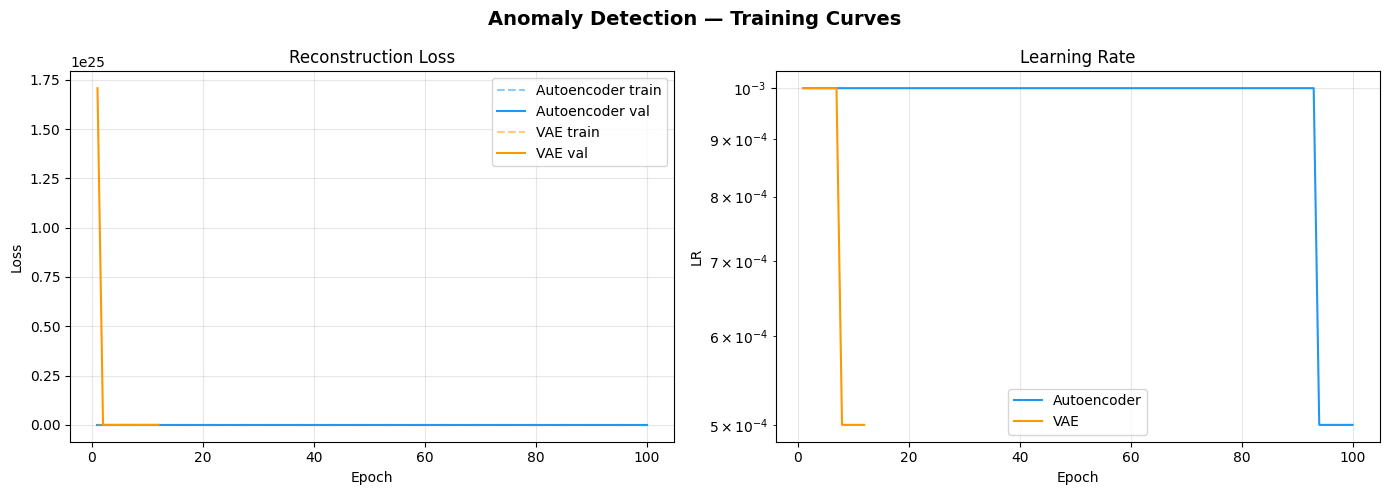

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Anomaly Detection — Training Curves', fontsize=14, fontweight='bold')

for name, history, color in [('Autoencoder', ae_history, '#2196F3'), ('VAE', vae_history, '#FF9800')]:
    epochs_range = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs_range, history['train_loss'], '--', color=color, alpha=0.5, label=f'{name} train')
    axes[0].plot(epochs_range, history['val_loss'], '-', color=color, label=f'{name} val')
    axes[1].plot(epochs_range, history['lr'], '-', color=color, label=name)

axes[0].set_title('Reconstruction Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Learning Rate'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR')
axes[1].set_yscale('log'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 9. Isolation Forest

In [11]:
print('Training Isolation Forest...')

# Contamination = approximate attack ratio
contamination = float(y_train.mean())
contamination = min(max(contamination, 0.01), 0.45)
print(f'  Contamination ratio: {contamination:.3f}')

isolation_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=contamination,
    max_features=1.0,
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

# Train on ALL data (Isolation Forest is unsupervised)
isolation_forest.fit(X_train)
print('  Isolation Forest trained.')

# Score: negative = anomaly, positive = normal
if_scores_train = -isolation_forest.decision_function(X_train)  # Negate so higher = more anomalous
if_scores_val = -isolation_forest.decision_function(X_val)
if_scores_test = -isolation_forest.decision_function(X_test)

print(f'  IF score range (train): [{if_scores_train.min():.4f}, {if_scores_train.max():.4f}]')
print(f'  IF score range (test):  [{if_scores_test.min():.4f}, {if_scores_test.max():.4f}]')

Training Isolation Forest...
  Contamination ratio: 0.450
  Isolation Forest trained.
  IF score range (train): [-0.0358, 0.2451]
  IF score range (test):  [-0.0358, 0.2250]


---
## 10. Compute Anomaly Scores for All Methods

In [12]:
# Autoencoder scores
ae_scores_val, ae_labels_val = ae_trainer.compute_anomaly_scores(val_loader)
ae_scores_test, ae_labels_test = ae_trainer.compute_anomaly_scores(test_loader)

# VAE scores
vae_scores_val, vae_labels_val = vae_trainer.compute_anomaly_scores(val_loader)
vae_scores_test, vae_labels_test = vae_trainer.compute_anomaly_scores(test_loader)

print('Anomaly scores computed.')
print(f'  AE val range:  [{ae_scores_val.min():.4f}, {ae_scores_val.max():.4f}]')
print(f'  VAE val range: [{vae_scores_val.min():.4f}, {vae_scores_val.max():.4f}]')
print(f'  IF val range:  [{if_scores_val.min():.4f}, {if_scores_val.max():.4f}]')

Anomaly scores computed.
  AE val range:  [592502.1250, 278964283113472.0000]
  VAE val range: [0.1966, 273605824872448.0000]
  IF val range:  [-0.0358, 0.2344]


## 11. Threshold Calibration

Find optimal threshold on validation set that maximizes F1 score.

In [13]:
def find_optimal_threshold(scores, labels, method_name: str, n_thresholds: int = 200):
    """
    Find the threshold that maximizes F1 score on validation set.
    Returns: optimal threshold, best F1, AUC-ROC.
    """
    thresholds = np.linspace(np.percentile(scores, 1), np.percentile(scores, 99), n_thresholds)
    
    best_f1 = 0
    best_thresh = thresholds[0]
    f1_scores = []
    
    for thresh in thresholds:
        preds = (scores >= thresh).astype(int)
        f1 = f1_score(labels, preds, average='binary', zero_division=0)
        f1_scores.append(f1)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    try:
        auc = roc_auc_score(labels, scores)
    except ValueError:
        auc = 0.0
    
    print(f'  {method_name}: Best threshold={best_thresh:.4f}, F1={best_f1:.4f}, AUC={auc:.4f}')
    
    return best_thresh, best_f1, auc, thresholds, f1_scores

print('\nThreshold calibration (on validation set):')
ae_thresh, ae_f1, ae_auc, ae_threshs, ae_f1s = find_optimal_threshold(
    ae_scores_val, ae_labels_val, 'Autoencoder'
)
vae_thresh, vae_f1, vae_auc, vae_threshs, vae_f1s = find_optimal_threshold(
    vae_scores_val, vae_labels_val, 'VAE'
)
if_thresh, if_f1, if_auc, if_threshs, if_f1s = find_optimal_threshold(
    if_scores_val, y_val, 'Isolation Forest'
)


Threshold calibration (on validation set):
  Autoencoder: Best threshold=1373701.8750, F1=0.6706, AUC=0.4306
  VAE: Best threshold=0.2035, F1=0.6636, AUC=0.3675
  Isolation Forest: Best threshold=-0.0358, F1=0.6724, AUC=0.2733


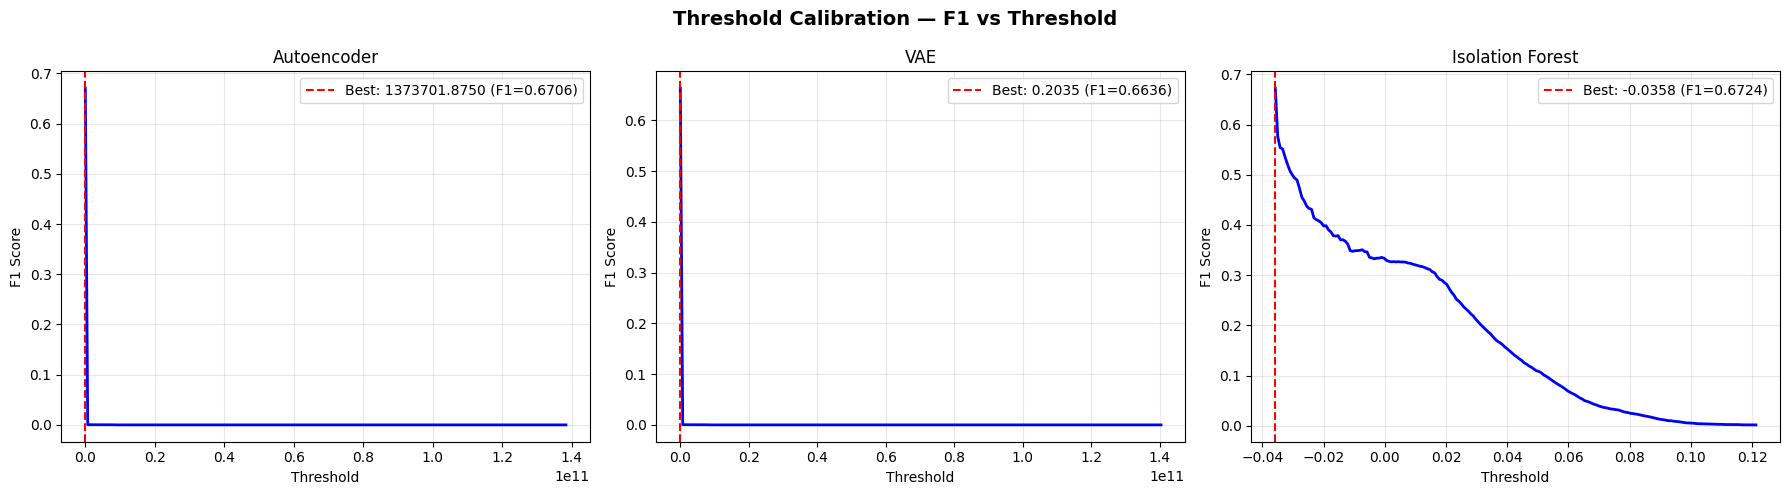

In [14]:
# Plot threshold vs F1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Threshold Calibration — F1 vs Threshold', fontsize=14, fontweight='bold')

for ax, name, threshs, f1s, best_t, best_f in [
    (axes[0], 'Autoencoder', ae_threshs, ae_f1s, ae_thresh, ae_f1),
    (axes[1], 'VAE', vae_threshs, vae_f1s, vae_thresh, vae_f1),
    (axes[2], 'Isolation Forest', if_threshs, if_f1s, if_thresh, if_f1),
]:
    ax.plot(threshs, f1s, 'b-', linewidth=2)
    ax.axvline(best_t, color='r', linestyle='--', label=f'Best: {best_t:.4f} (F1={best_f:.4f})')
    ax.set_title(name); ax.set_xlabel('Threshold'); ax.set_ylabel('F1 Score')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 12. Ensemble Anomaly Scorer

In [15]:
class EnsembleAnomalyScorer:
    """
    Combines multiple anomaly detection methods into an ensemble score.
    Normalizes each score to [0,1] then takes weighted average.
    """
    
    def __init__(self):
        self.scalers = {}
        self.weights = {}
        self.threshold = None
    
    def fit(self, scores_dict: dict, labels: np.ndarray, weights: dict = None):
        """
        Fit normalizers and find optimal ensemble threshold.
        scores_dict: {'method_name': scores_array}
        """
        # Default equal weights
        if weights is None:
            weights = {k: 1.0 / len(scores_dict) for k in scores_dict}
        self.weights = weights
        
        # Fit MinMax scalers for each method
        normalized_scores = {}
        for name, scores in scores_dict.items():
            scaler = MinMaxScaler()
            normalized = scaler.fit_transform(scores.reshape(-1, 1)).flatten()
            self.scalers[name] = scaler
            normalized_scores[name] = normalized
        
        # Compute weighted ensemble score
        ensemble_scores = np.zeros(len(labels))
        for name, normalized in normalized_scores.items():
            ensemble_scores += self.weights[name] * normalized
        
        # Find optimal threshold
        self.threshold, best_f1, auc, _, _ = find_optimal_threshold(
            ensemble_scores, labels, 'Ensemble'
        )
        
        return ensemble_scores
    
    def predict_scores(self, scores_dict: dict) -> np.ndarray:
        """Compute ensemble anomaly scores for new data."""
        ensemble_scores = np.zeros(len(next(iter(scores_dict.values()))))
        for name, scores in scores_dict.items():
            normalized = self.scalers[name].transform(scores.reshape(-1, 1)).flatten()
            normalized = np.clip(normalized, 0, 1)
            ensemble_scores += self.weights[name] * normalized
        return ensemble_scores
    
    def predict(self, scores_dict: dict) -> np.ndarray:
        """Predict anomaly labels (0=normal, 1=anomaly)."""
        ensemble_scores = self.predict_scores(scores_dict)
        return (ensemble_scores >= self.threshold).astype(int)

# Build ensemble
ensemble = EnsembleAnomalyScorer()

# Fit on validation set
val_scores_dict = {
    'ae': ae_scores_val,
    'vae': vae_scores_val,
    'if': if_scores_val,
}

# Weight by individual AUC performance
total_auc = ae_auc + vae_auc + if_auc
weights = {
    'ae': ae_auc / total_auc,
    'vae': vae_auc / total_auc,
    'if': if_auc / total_auc,
}
print(f'\nEnsemble weights: {weights}')

ensemble_val_scores = ensemble.fit(val_scores_dict, ae_labels_val, weights=weights)
print(f'Ensemble threshold: {ensemble.threshold:.4f}')


Ensemble weights: {'ae': 0.4019052833512538, 'vae': 0.34298886343425244, 'if': 0.2551058532144939}
  Ensemble: Best threshold=0.0000, F1=0.6636, AUC=0.2733
Ensemble threshold: 0.0000


---
## 13. Test Set Evaluation

In [16]:
def evaluate_anomaly_detector(scores, labels, threshold, method_name):
    """Evaluate anomaly detector on test set."""
    preds = (scores >= threshold).astype(int)
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='binary')
    try:
        auc = roc_auc_score(labels, scores)
        ap = average_precision_score(labels, scores)
    except ValueError:
        auc, ap = 0.0, 0.0
    
    print(f'\n{method_name}: Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | AP={ap:.4f}')
    print(classification_report(labels, preds, target_names=['Normal', 'Anomaly']))
    
    return {'method': method_name, 'accuracy': acc, 'f1': f1, 'auc': auc, 'ap': ap,
            'predictions': preds, 'scores': scores}

print('='*60)
print('  TEST SET EVALUATION')
print('='*60)

# Individual methods
ae_results = evaluate_anomaly_detector(ae_scores_test, ae_labels_test, ae_thresh, 'Autoencoder')
vae_results = evaluate_anomaly_detector(vae_scores_test, vae_labels_test, vae_thresh, 'VAE')
if_results = evaluate_anomaly_detector(if_scores_test, y_test, if_thresh, 'Isolation Forest')

# Ensemble
test_scores_dict = {
    'ae': ae_scores_test,
    'vae': vae_scores_test,
    'if': if_scores_test,
}
ensemble_test_scores = ensemble.predict_scores(test_scores_dict)
ensemble_results = evaluate_anomaly_detector(
    ensemble_test_scores, ae_labels_test, ensemble.threshold, 'Ensemble'
)

  TEST SET EVALUATION

Autoencoder: Acc=0.5081 | F1=0.6713 | AUC=0.4369 | AP=0.4709
              precision    recall  f1-score   support

      Normal       0.58      0.01      0.02     10363
     Anomaly       0.51      0.99      0.67     10637

    accuracy                           0.51     21000
   macro avg       0.54      0.50      0.35     21000
weighted avg       0.54      0.51      0.35     21000


VAE: Acc=0.4952 | F1=0.6624 | AUC=0.3740 | AP=0.4378
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     10363
     Anomaly       0.50      0.98      0.66     10637

    accuracy                           0.50     21000
   macro avg       0.25      0.49      0.33     21000
weighted avg       0.25      0.50      0.34     21000


Isolation Forest: Acc=0.5065 | F1=0.6724 | AUC=0.2698 | AP=0.3932
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     10363
     Anomaly       0.51      1.0

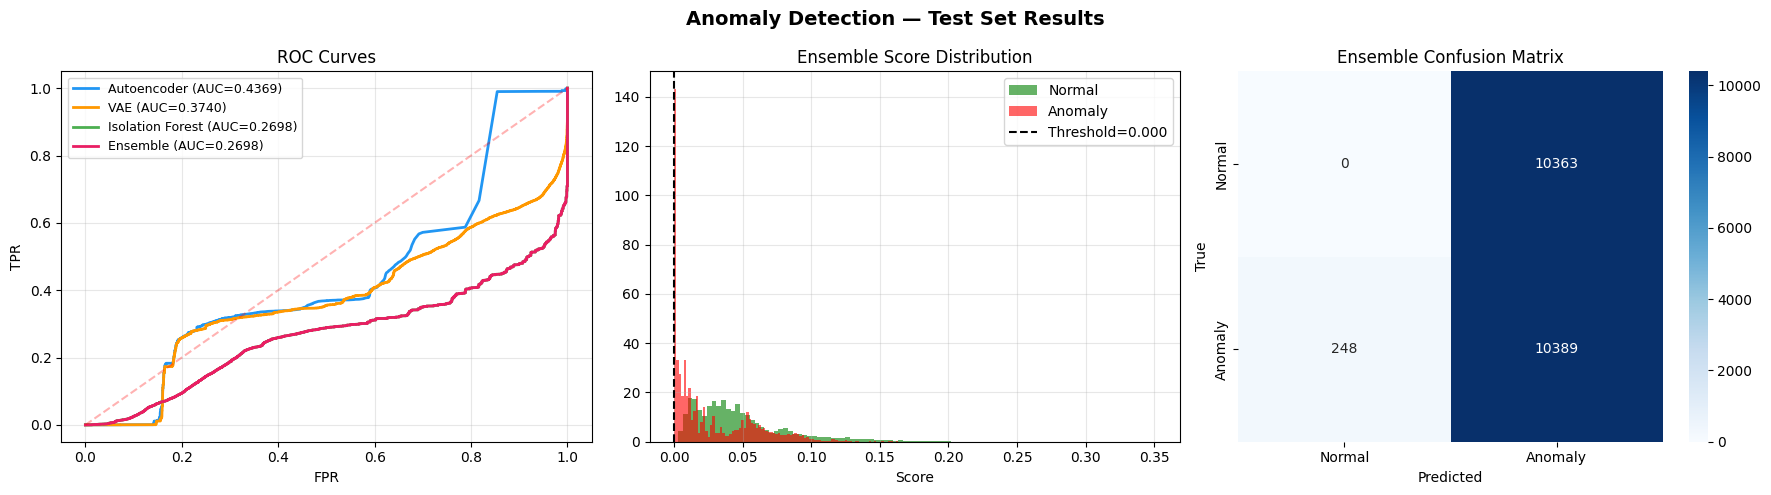

In [17]:
# Visualization: ROC curves for all methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Anomaly Detection — Test Set Results', fontsize=14, fontweight='bold')

# ROC Curves
for name, scores, labels, color in [
    ('Autoencoder', ae_scores_test, ae_labels_test, '#2196F3'),
    ('VAE', vae_scores_test, vae_labels_test, '#FF9800'),
    ('Isolation Forest', if_scores_test, y_test, '#4CAF50'),
    ('Ensemble', ensemble_test_scores, ae_labels_test, '#E91E63'),
]:
    try:
        fpr, tpr, _ = roc_curve(labels, scores)
        auc = roc_auc_score(labels, scores)
        axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')
    except ValueError:
        pass

axes[0].plot([0,1], [0,1], 'r--', alpha=0.3)
axes[0].set_title('ROC Curves'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Score distributions (Ensemble)
normal_scores = ensemble_test_scores[ae_labels_test == 0]
anomaly_scores = ensemble_test_scores[ae_labels_test == 1]
axes[1].hist(normal_scores, bins=100, alpha=0.6, label='Normal', color='green', density=True)
axes[1].hist(anomaly_scores, bins=100, alpha=0.6, label='Anomaly', color='red', density=True)
axes[1].axvline(ensemble.threshold, color='black', linestyle='--', label=f'Threshold={ensemble.threshold:.3f}')
axes[1].set_title('Ensemble Score Distribution'); axes[1].set_xlabel('Score'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix (Ensemble)
cm = confusion_matrix(ae_labels_test, ensemble_results['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[2].set_title('Ensemble Confusion Matrix'); axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

plt.tight_layout(); plt.show()

In [18]:
# Comparison table
comparison_df = pd.DataFrame([
    {'Method': r['method'], 'Accuracy': r['accuracy'], 'F1': r['f1'], 'AUC': r['auc'], 'AP': r['ap']}
    for r in [ae_results, vae_results, if_results, ensemble_results]
]).sort_values('F1', ascending=False)

print('\n' + '='*60)
print('  ANOMALY DETECTION COMPARISON')
print('='*60)
print(comparison_df.to_string(index=False))


  ANOMALY DETECTION COMPARISON
          Method  Accuracy       F1      AUC       AP
Isolation Forest  0.506524 0.672440 0.269848 0.393170
     Autoencoder  0.508143 0.671334 0.436946 0.470852
             VAE  0.495238 0.662420 0.373953 0.437821
        Ensemble  0.494714 0.661952 0.269826 0.387003


---
## 14. Save Models & Artifacts

In [19]:
anomaly_dir = MODELS_DIR / 'anomaly_detection'
anomaly_dir.mkdir(parents=True, exist_ok=True)

# Save Autoencoder
torch.save({
    'model_state_dict': ae_model.state_dict(),
    'model_class': 'DeepAutoencoder',
    'n_features': N_FEATURES,
    'latent_dim': 16,
    'threshold': float(ae_thresh),
    'history': ae_history,
    'dataset': DATASET_NAME,
    'timestamp': datetime.now().isoformat(),
}, anomaly_dir / 'autoencoder.pth')
print(f'Saved autoencoder')

# Save VAE
torch.save({
    'model_state_dict': vae_model.state_dict(),
    'model_class': 'VAEAnomalyDetector',
    'n_features': N_FEATURES,
    'latent_dim': 16,
    'threshold': float(vae_thresh),
    'history': vae_history,
    'dataset': DATASET_NAME,
    'timestamp': datetime.now().isoformat(),
}, anomaly_dir / 'vae.pth')
print(f'Saved VAE')

# Save Isolation Forest
joblib.dump({
    'model': isolation_forest,
    'threshold': float(if_thresh),
    'dataset': DATASET_NAME,
    'timestamp': datetime.now().isoformat(),
}, anomaly_dir / 'isolation_forest.joblib')
print(f'Saved Isolation Forest')

# Save Ensemble config
joblib.dump({
    'scalers': ensemble.scalers,
    'weights': ensemble.weights,
    'threshold': ensemble.threshold,
    'methods': ['ae', 'vae', 'if'],
    'dataset': DATASET_NAME,
    'timestamp': datetime.now().isoformat(),
}, anomaly_dir / 'ensemble_config.joblib')
print(f'Saved ensemble config')

# Save comparison
comparison_df.to_csv(anomaly_dir / 'anomaly_comparison.csv', index=False)

print(f'\nAll anomaly detection models saved to {anomaly_dir}')

Saved autoencoder
Saved VAE
Saved Isolation Forest
Saved ensemble config

All anomaly detection models saved to ..\models\anomaly_detection


In [20]:
# Inference helper
def load_anomaly_detector(models_dir: str, device: str = 'cpu'):
    """
    Load all anomaly detection models for inference.
    Returns: ae_model, vae_model, if_model, ensemble_config
    """
    models_path = Path(models_dir)
    
    # Load AE
    ae_ckpt = torch.load(models_path / 'autoencoder.pth', map_location=device, weights_only=False)
    ae = DeepAutoencoder(ae_ckpt['n_features'], ae_ckpt['latent_dim'])
    ae.load_state_dict(ae_ckpt['model_state_dict'])
    ae.to(device).eval()
    
    # Load VAE
    vae_ckpt = torch.load(models_path / 'vae.pth', map_location=device, weights_only=False)
    vae = VAEAnomalyDetector(vae_ckpt['n_features'], vae_ckpt['latent_dim'])
    vae.load_state_dict(vae_ckpt['model_state_dict'])
    vae.to(device).eval()
    
    # Load IF
    if_data = joblib.load(models_path / 'isolation_forest.joblib')
    
    # Load ensemble config
    ens_config = joblib.load(models_path / 'ensemble_config.joblib')
    
    return ae, vae, if_data['model'], ens_config

print('\n✓ Notebook 03 complete. Ready for Notebook 04 (Attack Classification).')


✓ Notebook 03 complete. Ready for Notebook 04 (Attack Classification).


In [21]:
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
print('Memory freed.')

Memory freed.
